### Distribution of grader **overall** scores

Single plot with **overlaid** histograms (semi-transparent): model output (`generated/`), ground-truth Bach (`jsb_chorales_in_c/test`), and random SATB (`random_chorales/`). Scores come from `bach_grader.py` (reference: `jsb_chorales_in_c/valid`).

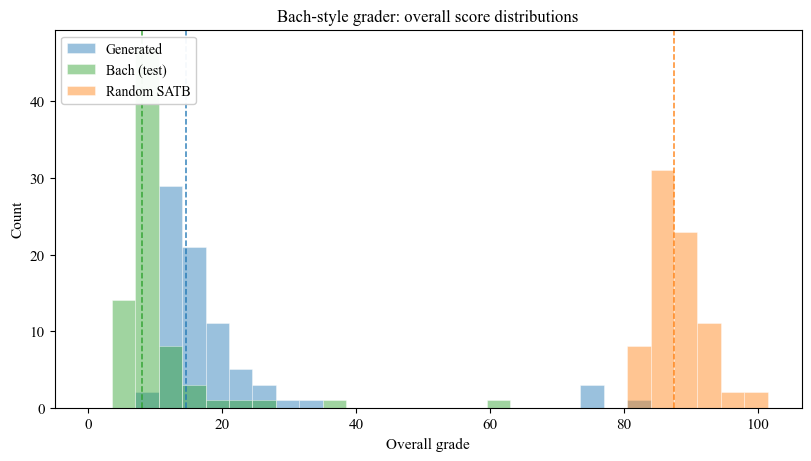

N=77 generated, 77 Bach test, 77 random — mean overall: 19.13, 10.02, 88.02


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
    }
)

repo = Path(".").resolve()

def load_overall(path: Path) -> np.ndarray:
    data = json.loads(path.read_text())
    return np.array([v["overall_grade"] for v in data.values()], dtype=float)

gen = load_overall(repo / "generated" / "bach_grader_results.json")
bach = load_overall(repo / "jsb_chorales_in_c" / "test" / "bach_grader_baseline.json")
rnd = load_overall(repo / "random_chorales" / "bach_grader_random_baseline.json")

# Shared bin edges for all three distributions
xmax = float(max(gen.max(), bach.max(), rnd.max()))
bins = np.linspace(0.0, xmax * 1.02, 30)

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)

styles = [
    ("Generated", gen, "#1f77b4"),
    ("Bach (test)", bach, "#2ca02c"),
    ("Random SATB", rnd, "#ff7f0e"),
]
alpha_hist = 0.45

for label, arr, c in styles:
    ax.hist(
        arr,
        bins=bins,
        alpha=alpha_hist,
        label=label,
        color=c,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.axvline(np.median(arr), color=c, linestyle="--", linewidth=1.1, alpha=0.9)

ax.set_xlabel("Overall grade")
ax.set_ylabel("Count")
ax.set_title("Bach-style grader: overall score distributions")
ax.legend(loc="upper left", fontsize=10, framealpha=0.95)
plt.show()

print(
    f"N={len(gen)} generated, {len(bach)} Bach test, {len(rnd)} random — "
    f"mean overall: {gen.mean():.2f}, {bach.mean():.2f}, {rnd.mean():.2f}"
)
